# 📊 Tâche B1 — Analyse Exploratoire (EDA)
### Personne B · Phase 1

> **Prérequis :** ton binôme (Personne A) a déjà exécuté ses notebooks.  
> Ce notebook lit directement le fichier `donnees_propres.json` qu'il a produit.

---
**Objectif :** comprendre la structure des données avant de choisir le modèle.  
**Ce qu'on analyse :**
- Distribution des longueurs (livres + résumés)
- Ratio de compression
- Distribution du nombre de chunks
- Mots les plus fréquents
- Qualité des données (vides, trop courts, doublons)

**Ce qu'on produit :** `rapport_eda.json` → utilisé par B2 pour choisir le tokenizer

## 0. Installation des dépendances

In [1]:
!pip install matplotlib seaborn pandas nltk wordcloud --quiet

## 1. Chargement du fichier de Personne A

In [2]:
import json
import pandas as pd

# ✅ On lit le fichier produit par le binôme (Personne A)
with open("donnees_propres.json", "r") as f:
    donnees = json.load(f)

print(f"✅ {len(donnees)} exemples chargés depuis donnees_propres.json")
print(f"\nStructure d'un exemple :")
for cle, val in donnees[0].items():
    if cle == 'chunks':
        print(f"  {cle} → liste de {len(val)} chunks")
    else:
        print(f"  {cle} → {str(val)[:80]}")

✅ 100 exemples chargés depuis donnees_propres.json

Structure d'un exemple :
  chunks → liste de 14 chunks
  resume → Before any characters appear, the time and geography are made clear. Though it i
  nb_chunks → 14


## 2. Construction du DataFrame d'analyse

In [3]:
# Construire un DataFrame à partir des données de Personne A
rows = []
for ex in donnees:
    texte_complet = ' '.join(ex['chunks'])          # reconstruire le texte
    resume        = ex['resume']
    nb_mots_livre = len(texte_complet.split())
    nb_mots_resume = len(resume.split())
    nb_chunks      = ex['nb_chunks']
    ratio          = nb_mots_livre / nb_mots_resume if nb_mots_resume > 0 else 0

    rows.append({
        'nb_mots_livre':  nb_mots_livre,
        'nb_mots_resume': nb_mots_resume,
        'nb_chunks':      nb_chunks,
        'ratio_compression': round(ratio, 2),
        'resume_vide':    (nb_mots_resume == 0),
        'resume_court':   (nb_mots_resume < 50),
    })

df = pd.DataFrame(rows)
print(df.describe().round(1))

       nb_mots_livre  nb_mots_resume  nb_chunks  ratio_compression
count          100.0           100.0      100.0              100.0
mean          5425.2           353.5       11.1               20.3
std           1515.2           215.7        3.0               10.8
min           3204.0            86.0        7.0                5.2
25%           4365.0           188.8        9.0               12.4
50%           5506.0           319.0       11.0               17.9
75%           5940.0           476.5       12.0               25.8
max           9944.0           959.0       20.0               49.1


## 3. Visualisations — Distributions

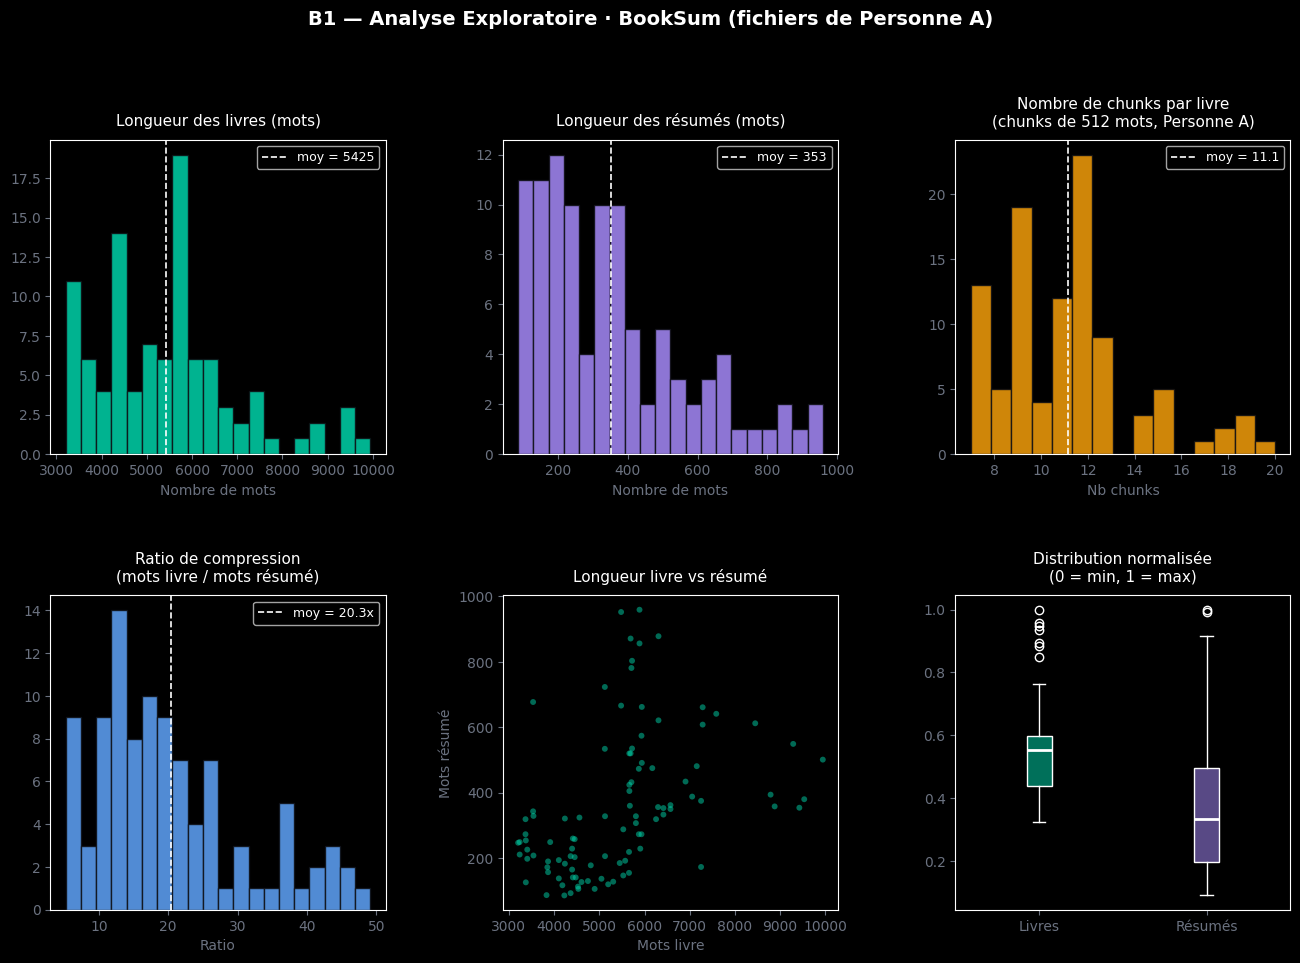

✅ Graphiques sauvegardés → eda_distributions.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

plt.style.use('dark_background')
TEAL   = '#00d4aa'
PURPLE = '#a78bfa'
AMBER  = '#f59e0b'
BLUE   = '#60a5fa'

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- 1. Distribution longueurs livres ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['nb_mots_livre'], bins=20, color=TEAL, alpha=0.85, edgecolor='#0e0f14')
ax1.axvline(df['nb_mots_livre'].mean(), color='white', ls='--', lw=1.2, label=f"moy = {df['nb_mots_livre'].mean():.0f}")
ax1.set_title('Longueur des livres (mots)', color='white', fontsize=11, pad=10)
ax1.set_xlabel('Nombre de mots', color='#6b7280')
ax1.legend(fontsize=9)
ax1.tick_params(colors='#6b7280')

# --- 2. Distribution longueurs résumés ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df['nb_mots_resume'], bins=20, color=PURPLE, alpha=0.85, edgecolor='#0e0f14')
ax2.axvline(df['nb_mots_resume'].mean(), color='white', ls='--', lw=1.2, label=f"moy = {df['nb_mots_resume'].mean():.0f}")
ax2.set_title('Longueur des résumés (mots)', color='white', fontsize=11, pad=10)
ax2.set_xlabel('Nombre de mots', color='#6b7280')
ax2.legend(fontsize=9)
ax2.tick_params(colors='#6b7280')

# --- 3. Distribution nb_chunks ---
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df['nb_chunks'], bins=15, color=AMBER, alpha=0.85, edgecolor='#0e0f14')
ax3.axvline(df['nb_chunks'].mean(), color='white', ls='--', lw=1.2, label=f"moy = {df['nb_chunks'].mean():.1f}")
ax3.set_title('Nombre de chunks par livre\n(chunks de 512 mots, Personne A)', color='white', fontsize=11, pad=10)
ax3.set_xlabel('Nb chunks', color='#6b7280')
ax3.legend(fontsize=9)
ax3.tick_params(colors='#6b7280')

# --- 4. Ratio de compression ---
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df['ratio_compression'], bins=20, color=BLUE, alpha=0.85, edgecolor='#0e0f14')
ax4.axvline(df['ratio_compression'].mean(), color='white', ls='--', lw=1.2, label=f"moy = {df['ratio_compression'].mean():.1f}x")
ax4.set_title('Ratio de compression\n(mots livre / mots résumé)', color='white', fontsize=11, pad=10)
ax4.set_xlabel('Ratio', color='#6b7280')
ax4.legend(fontsize=9)
ax4.tick_params(colors='#6b7280')

# --- 5. Scatter livre vs résumé ---
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(df['nb_mots_livre'], df['nb_mots_resume'],
            alpha=0.5, color=TEAL, s=18, edgecolors='none')
ax5.set_title('Longueur livre vs résumé', color='white', fontsize=11, pad=10)
ax5.set_xlabel('Mots livre', color='#6b7280')
ax5.set_ylabel('Mots résumé', color='#6b7280')
ax5.tick_params(colors='#6b7280')

# --- 6. Boxplot comparatif normalisé ---
ax6 = fig.add_subplot(gs[1, 2])
bp_data  = [df['nb_mots_livre'] / df['nb_mots_livre'].max(),
             df['nb_mots_resume'] / df['nb_mots_resume'].max()]
bp = ax6.boxplot(bp_data, patch_artist=True, notch=False,
                 medianprops={'color': 'white', 'linewidth': 2})
bp['boxes'][0].set_facecolor(TEAL + '88')
bp['boxes'][1].set_facecolor(PURPLE + '88')
ax6.set_xticklabels(['Livres', 'Résumés'], color='#6b7280')
ax6.set_title('Distribution normalisée\n(0 = min, 1 = max)', color='white', fontsize=11, pad=10)
ax6.tick_params(colors='#6b7280')

fig.suptitle('B1 — Analyse Exploratoire · BookSum (fichiers de Personne A)',
             color='white', fontsize=14, fontweight='bold', y=1.01)

plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight',
            facecolor='#0e0f14', edgecolor='none')
plt.show()
print("✅ Graphiques sauvegardés → eda_distributions.png")

## 4. Analyse des mots fréquents

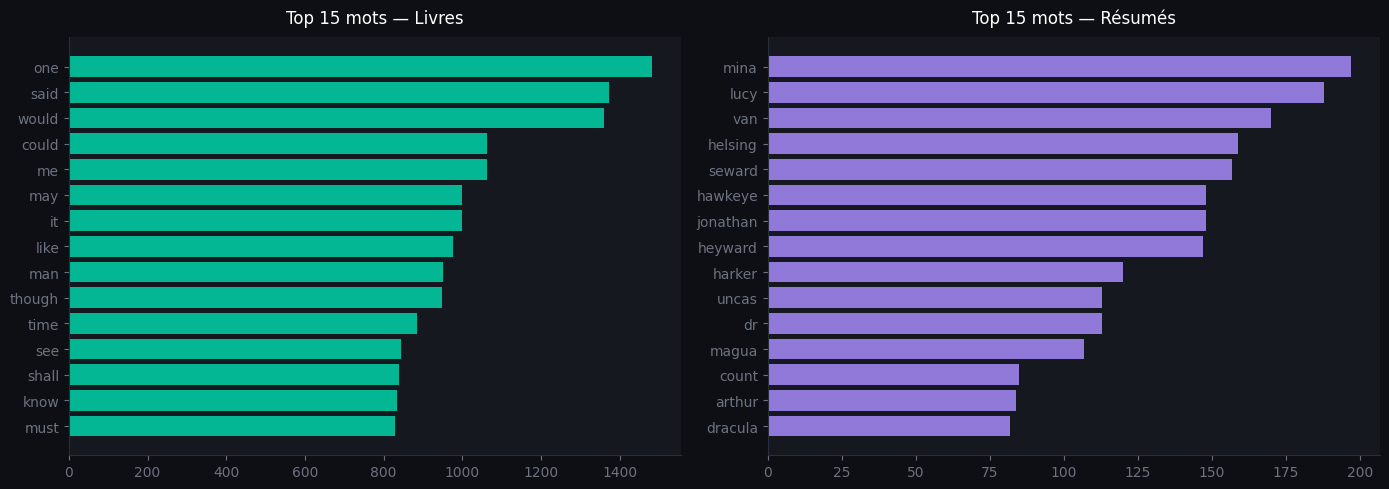

✅ Graphique mots fréquents → eda_top_words.png


In [5]:
import nltk
from collections import Counter
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

STOP = set(stopwords.words('english'))

def top_words(textes, n=15):
    """Renvoie les n mots les plus fréquents (hors stopwords)."""
    all_words = []
    for t in textes:
        mots = [w.lower().strip('.,!?;:"\'')
                for w in t.split()
                if w.lower() not in STOP and len(w) > 2]
        all_words.extend(mots)
    return Counter(all_words).most_common(n)

# Textes livres et résumés
textes_livres  = [' '.join(ex['chunks']) for ex in donnees]
textes_resumes = [ex['resume'] for ex in donnees]

top_livres  = top_words(textes_livres)
top_resumes = top_words(textes_resumes)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5),
                                facecolor='#0e0f14')

for ax, data, color, titre in [
    (ax1, top_livres,  TEAL,   'Top 15 mots — Livres'),
    (ax2, top_resumes, PURPLE, 'Top 15 mots — Résumés')
]:
    mots, freqs = zip(*data)
    ax.barh(mots[::-1], freqs[::-1], color=color, alpha=0.85)
    ax.set_title(titre, color='white', fontsize=12, pad=10)
    ax.tick_params(colors='#6b7280')
    ax.set_facecolor('#161820')
    ax.spines['bottom'].set_color('#2a2d3a')
    ax.spines['left'].set_color('#2a2d3a')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('eda_top_words.png', dpi=150, bbox_inches='tight',
            facecolor='#0e0f14')
plt.show()
print("✅ Graphique mots fréquents → eda_top_words.png")

## 5. Détection des problèmes qualité

In [6]:
print("=" * 50)
print("RAPPORT QUALITÉ DES DONNÉES")
print("=" * 50)

# Résumés vides
vides = df['resume_vide'].sum()
print(f"\n❌ Résumés vides       : {vides} ({vides/len(df)*100:.1f}%)")

# Résumés trop courts
courts = df['resume_court'].sum()
print(f"⚠️  Résumés < 50 mots   : {courts} ({courts/len(df)*100:.1f}%)")

# Doublons (résumés identiques)
resumes = [ex['resume'] for ex in donnees]
doublons = len(resumes) - len(set(resumes))
print(f"⚠️  Résumés doublons    : {doublons} ({doublons/len(df)*100:.1f}%)")

# Livres très courts (< 1000 mots)
trop_courts = (df['nb_mots_livre'] < 1000).sum()
print(f"⚠️  Livres < 1000 mots  : {trop_courts}")

# Livres avec un seul chunk
un_chunk = (df['nb_chunks'] == 1).sum()
print(f"ℹ️  Livres avec 1 chunk : {un_chunk}")

print("\n" + "=" * 50)
print("STATISTIQUES GLOBALES")
print("=" * 50)
print(f"\nTotal exemples         : {len(df)}")
print(f"Mots moy. / livre      : {df['nb_mots_livre'].mean():.0f}")
print(f"Mots moy. / résumé     : {df['nb_mots_resume'].mean():.0f}")
print(f"Ratio compression moy. : {df['ratio_compression'].mean():.1f}x")
print(f"Chunks moy. / livre    : {df['nb_chunks'].mean():.1f}")
print(f"Max chunks / livre     : {df['nb_chunks'].max()}")
print()

RAPPORT QUALITÉ DES DONNÉES

❌ Résumés vides       : 0 (0.0%)
⚠️  Résumés < 50 mots   : 0 (0.0%)
⚠️  Résumés doublons    : 0 (0.0%)
⚠️  Livres < 1000 mots  : 0
ℹ️  Livres avec 1 chunk : 0

STATISTIQUES GLOBALES

Total exemples         : 100
Mots moy. / livre      : 5425
Mots moy. / résumé     : 353
Ratio compression moy. : 20.3x
Chunks moy. / livre    : 11.1
Max chunks / livre     : 20



## 6. Export du rapport pour B2

In [8]:
# Ce fichier sera lu par ton notebook B2 (choix du tokenizer)
rapport = {
    "nb_exemples": int(len(df)),
    "longueur_livre": {
        "moyenne": round(float(df['nb_mots_livre'].mean()), 1),
        "min":     int(df['nb_mots_livre'].min()),
        "max":     int(df['nb_mots_livre'].max()),
        "std":     round(float(df['nb_mots_livre'].std()), 1)
    },
    "longueur_resume": {
        "moyenne": round(float(df['nb_mots_resume'].mean()), 1),
        "min":     int(df['nb_mots_resume'].min()),
        "max":     int(df['nb_mots_resume'].max()),
        "std":     round(float(df['nb_mots_resume'].std()), 1)
    },
    "chunks": {
        "taille_chunk_A": 512,           # paramètre utilisé par Personne A
        "overlap_A":      50,            # overlap utilisé par Personne A
        "moyenne_par_livre": round(float(df['nb_chunks'].mean()), 1),
        "max_par_livre":     int(df['nb_chunks'].max())
    },
    "ratio_compression_moyen": round(float(df['ratio_compression'].mean()), 1),
    "qualite": {
        "resumes_vides":   int(vides),
        "resumes_courts":  int(courts),
        "doublons":        int(doublons)
    },
    "recommandations_B2": [
        f"max_input_tokens recommandé : 512 (chunk size de Personne A)",
        f"max_target_tokens recommandé : {min(512, int(df['nb_mots_resume'].mean() * 1.5))}",
        "Tokenizer doit gérer du texte littéraire anglais",
        "Personne A utilise t5-small → utiliser le même tokenizer pour cohérence"
    ]
}

# ✅ CORRECTION : encoding="utf-8" pour Windows
with open("rapport_eda.json", "w", encoding="utf-8") as f:
    json.dump(rapport, f, indent=2, ensure_ascii=False)

print("✅ rapport_eda.json sauvegardé → sera utilisé par B2")
print()
print(json.dumps(rapport, indent=2, ensure_ascii=False))

✅ rapport_eda.json sauvegardé → sera utilisé par B2

{
  "nb_exemples": 100,
  "longueur_livre": {
    "moyenne": 5425.1,
    "min": 3204,
    "max": 9944,
    "std": 1515.2
  },
  "longueur_resume": {
    "moyenne": 353.5,
    "min": 86,
    "max": 959,
    "std": 215.7
  },
  "chunks": {
    "taille_chunk_A": 512,
    "overlap_A": 50,
    "moyenne_par_livre": 11.1,
    "max_par_livre": 20
  },
  "ratio_compression_moyen": 20.3,
  "qualite": {
    "resumes_vides": 0,
    "resumes_courts": 0,
    "doublons": 0
  },
  "recommandations_B2": [
    "max_input_tokens recommandé : 512 (chunk size de Personne A)",
    "max_target_tokens recommandé : 512",
    "Tokenizer doit gérer du texte littéraire anglais",
    "Personne A utilise t5-small → utiliser le même tokenizer pour cohérence"
  ]
}


---
## ✅ Résumé de la tâche B1

| Ce qu'on a fait | Fichier produit |
|---|---|
| Lu `donnees_propres.json` (Personne A) | — |
| Analysé distributions longueurs | `eda_distributions.png` |
| Analysé mots fréquents | `eda_top_words.png` |
| Détecté problèmes qualité | affiché dans cellule 5 |
| Exporté rapport pour B2 | `rapport_eda.json` |

**👉 Prochaine étape : ouvrir `02_B2_tokenizer.ipynb`**